# 9 Support Vector Machines



## 9.1 Maximum Margin Classifier

For now we focus on binary classification problems to understand the basics of the Support Vector Machine (SVM). One fundamental to grasp the support vector machine is the maximum margin classifier. The key idea is to find a separating hyperplane within the $ p $ dimensional feature space $ X $, which perfectly separate $ Y [0, 1] $. The planes are called hyper planes because they need $(p-1)$ dimensions to separate two classes in p dimensions. E.g. in a 2D plane a 1D line is needed with the following structure

$$
\beta_1 X_1 + beta_2 X_2 + \beta_0 = 0.
$$

We need to learn the beta parameters from our data. For every point where $X= (x_1, X_2)^T$ for which the above equation is true is a point on the line or hyper plane. The above equation can be easylie expanded to $p$ dimensions.

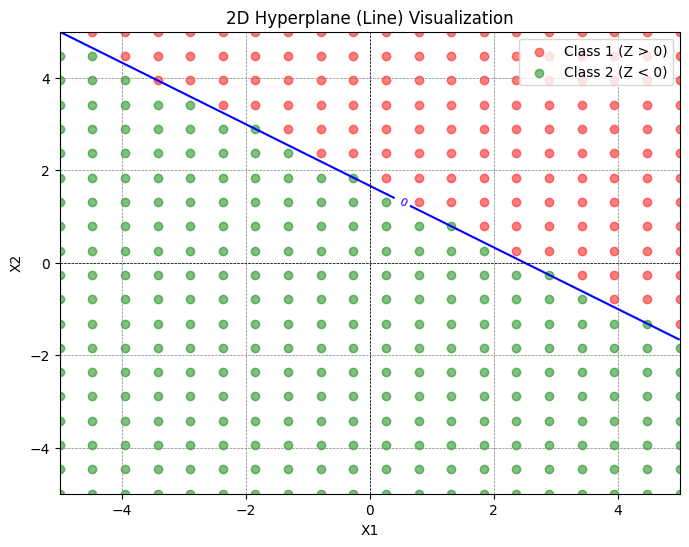

In [28]:
## Example of a 2D "hyperplane" 

#1. generate a grid of points in 2D space
import numpy as np
import matplotlib.pyplot as plt
x1 = np.linspace(-5, 5, 20)
x2 = np.linspace(-5, 5, 20)

X1, X2 = np.meshgrid(x1, x2)
points = np.c_[X1.ravel(), X2.ravel()]

#2. define a hyperplane (line) in 2D space
# e.g. 0.4*x1 + 0.6*x2 - 1 = 0
def hyperplane(x):
    return 0.4 * x[:, 0] + 0.6 * x[:, 1] - 1

#3. evaluate the hyperplane function on the grid points
Z = hyperplane(points).reshape(X1.shape)

#4. classify points based on the hyperplane
# Points where Z > 0 are on one side of the hyperplane, Z < 0 on the other side --> binary classification

points_class1 = points[Z.ravel() > 0]
points_class2 = points[Z.ravel() < 0]

#4. plot the hyperplane
plt.figure(figsize=(8, 6))
contour = plt.contour(X1, X2, Z, levels=[0], colors='blue')
plt.clabel(contour, inline=True, fontsize=8)
plt.scatter(points_class1[:, 0], points_class1[:, 1], color='red', alpha=0.5, label='Class 1 (Z > 0)')
plt.scatter(points_class2[:, 0], points_class2[:, 1], color='green', alpha=0.5, label='Class 2 (Z < 0)')
plt.title('2D Hyperplane (Line) Visualization')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
plt.legend()
plt.show()

## Classification using the hyper plane

In the 2D example we just evaluated the hyperplane and if the result is greater 0 it belongs to 1 side of the hyper plane and if 0 it belongs to the other side of the hyper plane. In this example we know and fixed the separating hyper plane and by design we get optimal separability as the data is on a regular grid and the classification was based on the linear classification boundry we just used to label the data.

In more general the separating hyperplane assumes a linear separation between the two classes therefor a separating hyperplane has with data X of shape n x p the property of 

$$
y_i (\beta_0 + \beta_1 X_1 + beta_2 X_2 + ... + \beta_p X_p ) > 0 for all i=1...n .
$$

If a separating hyperplane exists we can evaluate new $X_i$ by using the hyperplane equation and check the sign to assign a class label. Furthermore we can use the magnitude to see how far a sample is away from the plane in the p-1 dimensional space. 

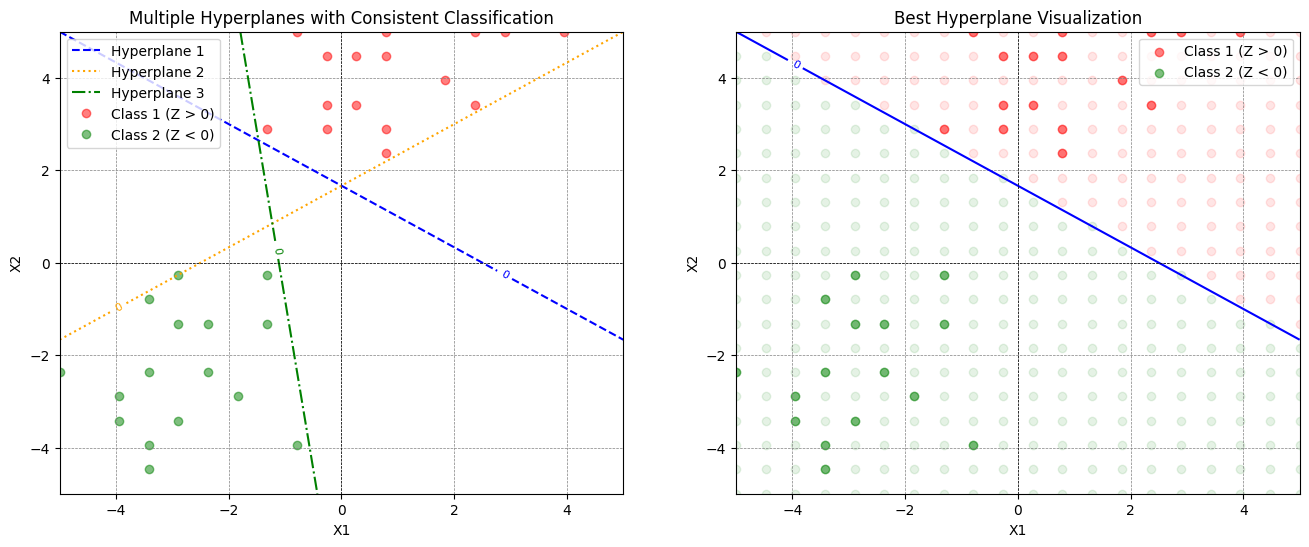

In [29]:
## Example with different hyperplane parameters fulfilling the same classification

# generate a grid of points in 2D space
x1 = np.linspace(-5, 5, 20)
x2 = np.linspace(-5, 5, 20)
X1, X2 = np.meshgrid(x1, x2)
points = np.c_[X1.ravel(), X2.ravel()]

# define a different hyperplane (line) in 2D space
# e.g. 0.8*x1 + 1.2*x2 - 2 = 0
def hyperplane1(x):
    return 0.8 * x[:, 0] + 1.2 * x[:, 1] - 2

def hyperplane2(x):
    return -0.2 * x[:, 0] + 0.3 * x[:, 1] - 0.5

def hyperplane3(x):
    return 0.9 * x[:, 0] + 0.123 * x[:, 1]  +1


# now find a subset of example points that are classified the same by all three hyperplanes
Z1 = hyperplane1(points).reshape(X1.shape)
Z2 = hyperplane2(points).reshape(X1.shape)
Z3 = hyperplane3(points).reshape(X1.shape)
mask = (Z1.ravel() > 0) & (Z2.ravel() > 0) & (Z3.ravel() > 0)
points_class1 = points[mask]
mask = (Z1.ravel() < 0) & (Z2.ravel() < 0) & (Z3.ravel() < 0)
points_class2 = points[mask]

# select a subset of points which are classified the same by all three hyperplanes
# 1.1 get the number of points in each class
num_class1 = points_class1.shape[0]
num_class2 = points_class2.shape[0]

# 1.2 determine the smaller class size
min_class_size = int(np.ceil(min(num_class1, num_class2) * 0.3)) # use 10% of the smaller class size for visualization

# 1.3 randomly select points from each class for visualization
np.random.seed(42)  # for reproducibility
selected_class1 = points_class1[np.random.choice(num_class1, min_class_size, replace=False)]
selected_class2 = points_class2[np.random.choice(num_class2, min_class_size, replace=False)]

# plot the hyperplanes and the selected points
# make 2 subplots left selecte " training points" with the hyperplanes, right the best hyperplane for the grid points (it is number 1 in this example)
plt.figure(figsize=(16, 6))
# left subplot
plt.subplot(1, 2, 1)
contour1 = plt.contour(X1, X2, hyperplane1(points).reshape(X1.shape), levels=[0], colors='blue', linestyles='dashed')
contour2 = plt.contour(X1, X2, hyperplane2(points).reshape(X1.shape), levels=[0], colors='orange', linestyles='dotted')
contour3 = plt.contour(X1, X2, hyperplane3(points).reshape(X1.shape), levels=[0], colors='green', linestyles='dashdot')
plt.clabel(contour1, inline=True, fontsize=8)   
plt.clabel(contour2, inline=True, fontsize=8)   
plt.clabel(contour3, inline=True, fontsize=8)
plt.scatter(selected_class1[:, 0], selected_class1[:, 1], color='red', alpha=0.5, label='Class 1 (Z > 0)')
plt.scatter(selected_class2[:, 0], selected_class2[:, 1], color='green', alpha=0.5, label='Class 2 (Z < 0)')
plt.title('Multiple Hyperplanes with Consistent Classification')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
# add legend for hyperplanes
blue_line = plt.Line2D([], [], color='blue', linestyle='dashed', label='Hyperplane 1')
orange_line = plt.Line2D([], [], color='orange', linestyle='dotted', label='Hyperplane 2')
green_line = plt.Line2D([], [], color='green', linestyle='dashdot', label='Hyperplane 3')
green_dots = plt.Line2D([], [], color='green', linestyle='None', marker='o', alpha=0.5, label='Class 2 (Z < 0)')
red_dots = plt.Line2D([], [], color='red', linestyle='None', marker='o', alpha=0.5, label='Class 1 (Z > 0)')
plt.legend(handles=[blue_line, orange_line, green_line, red_dots, green_dots])
# right subplot
plt.subplot(1, 2, 2)
contour_best = plt.contour(X1, X2, hyperplane1(points).reshape(X1.shape), levels=[0], colors='blue')
plt.clabel(contour_best, inline=True, fontsize=8)
plt.scatter(selected_class1[:, 0], selected_class1[:, 1], color='red', alpha=0.5, label='Class 1 (Z > 0)')
plt.scatter(selected_class2[:, 0], selected_class2[:, 1], color='green', alpha=0.5, label='Class 2 (Z < 0)')
# also show the full grid of points classified by the best hyperplane
all_points_class1 = points[hyperplane1(points) > 0]
all_points_class2 = points[hyperplane1(points) < 0]
plt.scatter(all_points_class1[:, 0], all_points_class1[:, 1], color='red', alpha=0.1)
plt.scatter(all_points_class2[:, 0], all_points_class2[:, 1], color='green', alpha=0.1)
plt.title('Best Hyperplane Visualization')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
plt.legend()
plt.show()


## The maxial margin classifier

The above example showed that there are many lines (hyperplanes) which lead to a perfect linear separation between the two classes but there is only one solution which separate the two classes best and thus is more robust or generalizes better compared to all other investigated classifiers. If the dataset is separable there exists a infinite number of linear combinations of the beta terms which lead to a perfect linear classification. The goal is now to find out of this infinite amount of solutions the best, which generalizes the best. 

A natural choice is to choose the maximal margin hyperplane which is the best separating hyperplane that is farthest away from the training samples. In order to find this plane we can calculate the perpendicular distance from each point to a hyperplane. The smallest distance to the hyperplane is the the margin. The goal is to maximize this margin and thus find the hyperplane which is farthest away from the margin. We can then classify again new observations $X$ based on which side of the maximum margin hyperplane the point lies as before.

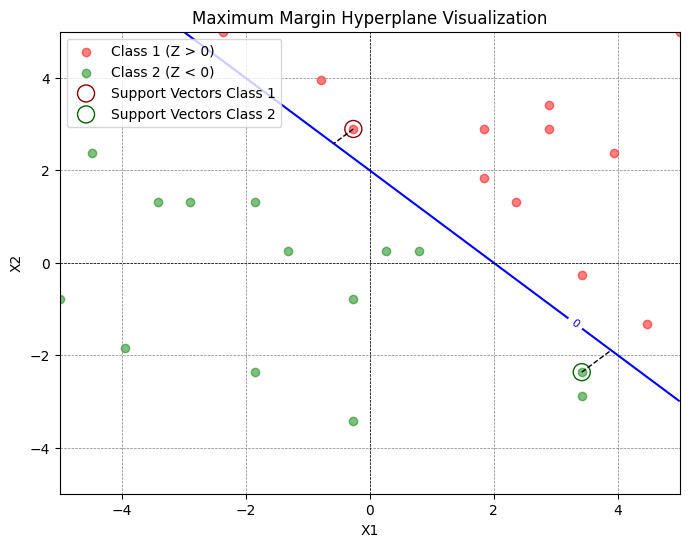

In [31]:
## Example with the maximum margin hyperplane
# generate a grid of points in 2D space as before
x1 = np.linspace(-5, 5, 20)
x2 = np.linspace(-5, 5, 20)
X1, X2 = np.meshgrid(x1, x2)
points = np.c_[X1.ravel(), X2.ravel()]
# define the maximum margin hyperplane (line) in 2D space
def max_margin_hyperplane(x):
    return 0.5 * x[:, 0] + 0.5 * x[:, 1] - 1


# evaluate the maximum margin hyperplane function on the grid points
Z_max_margin = max_margin_hyperplane(points).reshape(X1.shape)
# classify points based on the maximum margin hyperplane
points_class1_mm = points[Z_max_margin.ravel() > 0]
points_class2_mm = points[Z_max_margin.ravel() < 0]

# randomly select a subset of points from each class for visualization
np.random.seed(31)  # for reproducibility
num_class1_mm = points_class1_mm.shape[0]
num_class2_mm = points_class2_mm.shape[0]
# remove points to keep visualization clear also remove points with distance < margin
margin = 0.2
def distance_to_hyperplane(x):
    return np.abs(max_margin_hyperplane(x)) / np.sqrt(0.5**2 + 0.5**2)


min_class_size_mm = int(np.ceil(min(num_class1_mm, num_class2_mm) * 0.1)) # use 10% of the smaller class size for visualization
selected_class1_mm = points_class1_mm[np.random.choice(num_class1_mm, min_class_size_mm, replace=False)]
selected_class2_mm = points_class2_mm[np.random.choice(num_class2_mm, min_class_size_mm, replace=False)]

# remove points that are too close to the hyperplane
selected_class1_mm = selected_class1_mm[distance_to_hyperplane(selected_class1_mm) >= margin]
# remove points that are too close to the hyperplane
selected_class2_mm = selected_class2_mm[distance_to_hyperplane(selected_class2_mm) >= margin]

# find the closest points to the hyperplane from the randomly selected points to illustrate support vectors
distances_class1 = distance_to_hyperplane(selected_class1_mm)
distances_class2 = distance_to_hyperplane(selected_class2_mm)
# select all the support vectors (closest points) from each class

support_vector1 = selected_class1_mm[np.argmin(distances_class1)]
support_vector2 = selected_class2_mm[np.argmin(distances_class2)]
support_vectors = np.array([support_vector1, support_vector2])
# plot the maximum margin hyperplane
plt.figure(figsize=(8, 6))
contour_mm = plt.contour(X1, X2, Z_max_margin, levels=[0], colors='blue')
plt.clabel(contour_mm, inline=True, fontsize=8)
plt.scatter(selected_class1_mm[:, 0], selected_class1_mm[:, 1], color='red', alpha=0.5, label='Class 1 (Z > 0)')
plt.scatter(selected_class2_mm[:, 0], selected_class2_mm[:, 1], color='green', alpha=0.5, label='Class 2 (Z < 0)')
# highlight support vectors by outer circle in dark red or dark green
plt.scatter(support_vector1[0], support_vector1[1], facecolors='none', edgecolors='darkred', s=150, label='Support Vectors Class 1')
plt.scatter(support_vector2[0], support_vector2[1], facecolors='none', edgecolors='darkgreen', s=150, label='Support Vectors Class 2')

# illustrate the margin
for sv in support_vectors:
    a, b, c = 0.5, 0.5, -1.0
    val = a * sv[0] + b * sv[1] + c                       # signed distance numerator
    proj = sv - (val / (a*a + b*b)) * np.array([a, b])    # projection of sv onto the hyperplane
    x_vals = np.array([sv[0], proj[0]])
    y_vals = np.array([sv[1], proj[1]])
    plt.plot(x_vals, y_vals, 'k--', linewidth=1)


plt.title('Maximum Margin Hyperplane Visualization')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
plt.legend()
plt.show()